# Tier 0.5 — diagnosing the real driver of the AR–ER gap

The Tier-0 gap construction is **accepted and unchanged**:
`Gap_field = 1 − Spearman(SpringRank prestige, Scorecard bachelor's EARN_MDN_4YR)`.
AR = research/PhD-level (academic-market price); ER = undergraduate mass (labor-market
price). That *is* the AR–ER distinction, not a confound.

We test **four competing explanators** of the cross-field gap, each with a predicted
sign; none is dropped on significance:

1. **task_distance** (H2) — O\*NET Gathmann–Schönberg angular distance, academic-teacher
   vs CIP→SOC industry task vectors. *Predicted +.*
2. **earnings_dispersion** — within-field CV of institution bachelor's earnings.
   *Predicted − (compressed earnings ⇒ noisy Spearman ⇒ high gap).*
3. **grad-school pull** — IPEDS PhD/Bachelor completions ratio. *Predicted +.*
4. **price_wedge** — (industry−academic)/mean salary, SDR Table 54. *Predicted +ve in |.|.*
   (Note: the gap is RANK agreement between markets; the wedge is PRICE agreement.)

In [1]:
import os, sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
os.chdir(ROOT); sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from src import tier0 as T, tier0_5 as T5
from src.crosswalks import fields as F
pd.set_option("display.width", 170)

## Build the gap + the four explanators

In [2]:
prestige = T.load_prestige(); earn = T.load_earnings()
gaps = T.all_field_gaps(prestige, earn)
df = T5.assemble(gaps)   # task_distance(equal-weighted; OEWS blocked by BLS), earn_cv, doc_ba_ratio, price_wedge
cols = ["label", "gap", "task_distance", "earn_cv", "doc_ba_ratio", "price_wedge", "price_wedge_abs"]
print(df[cols].sort_values("gap").to_string(index=False,
      formatters={"gap": "{:.3f}".format, "task_distance": "{:.1f}".format,
                  "earn_cv": "{:.3f}".format, "doc_ba_ratio": "{:.3f}".format,
                  "price_wedge": "{:+.3f}".format, "price_wedge_abs": "{:.3f}".format}))

                 label   gap task_distance earn_cv doc_ba_ratio price_wedge price_wedge_abs
            Statistics 0.246          19.0   0.304        0.127      +0.690           0.690
      Computer Science 0.298          12.0   0.309        0.028      +0.500           0.500
             Economics 0.313          21.2   0.255        0.044      +0.503           0.503
     Political Science 0.343          15.4   0.178        0.020      +0.741           0.741
Mechanical Engineering 0.382          15.4   0.088        0.055      +0.371           0.371
           Mathematics 0.387          18.1   0.316        0.074      +0.690           0.690
               History 0.413          20.7   0.204        0.036         NaN             NaN
            Psychology 0.427          12.7   0.169        0.038      +0.283           0.283
             Sociology 0.430          21.3   0.164        0.026      +0.510           0.510
  Chemical Engineering 0.452          16.7   0.090        0.126      +0.227     

## Per-explanator relationship with the gap (predicted sign vs observed)

In [3]:
print(T5.per_explanator(df).to_string(index=False))

     explanator  n  spearman        p  predicted_sign  sign_ok                                              desc
  task_distance 20 -0.383459 0.095124               1    False                 gap RISES with task distance (H2)
        earn_cv 20 -0.413534 0.069921              -1     True gap FALLS as earnings dispersion rises (artifact)
   doc_ba_ratio 20  0.482707 0.031105               1     True                   gap RISES with grad-school pull
price_wedge_abs 17 -0.415696 0.097014               1    False                      gap RISES with |price wedge|


`task_distance` (H2) is **reversed** (−0.38, predicted +). `price_wedge` is reversed too.
Only **earnings_dispersion** (−0.41) and **grad-school pull** (+0.48, the one significant
explanator) carry the predicted sign.

## Decisive test: do CS *and* chemistry land where each mechanism predicts?
CS = integrated low-gap poster-child; chemistry = alleged counterexample (low task
distance yet high gap).

In [4]:
g = df[df.ok]
for v in ["task_distance", "earn_cv", "doc_ba_ratio", "price_wedge_abs"]:
    gg = g.dropna(subset=[v]).sort_values(v).reset_index(drop=True)
    rk = lambda k: (int(gg.index[gg.field_key == k][0]) + 1) if (gg.field_key == k).any() else None
    print(f"{v:<16} CS rank={rk('computer_science')}/{len(gg)}   "
          f"Chemistry rank={rk('chemistry')}/{len(gg)}")

task_distance    CS rank=2/20   Chemistry rank=12/20
earn_cv          CS rank=19/20   Chemistry rank=5/20
doc_ba_ratio     CS rank=3/20   Chemistry rank=18/20
price_wedge_abs  CS rank=12/17   Chemistry rank=11/17


Only **earnings dispersion** and **grad-school pull** place CS (low) and chemistry (high)
on the correct sides. Task distance puts chemistry only mid-pack — it cannot generate
chemistry's high gap.

## Combined standardized OLS (all four kept, none dropped)

In [5]:
mod, n, used = T5.combined_ols(df)
print(f"n = {n}")
print(pd.DataFrame({"coef": mod.params, "p": mod.pvalues}).round(4).to_string())
print(f"R2 = {mod.rsquared:.3f}   adj-R2 = {mod.rsquared_adj:.3f}")
print("\nSpearman among explanators (entanglement):")
print(df[["task_distance", "earn_cv", "doc_ba_ratio", "price_wedge_abs", "gap"]]
      .corr(method="spearman").round(2).to_string())

n = 17
                   coef       p
const            0.4665  0.0000
task_distance   -0.0477  0.1507
earn_cv         -0.0592  0.2090
doc_ba_ratio     0.0241  0.4697
price_wedge_abs  0.0101  0.8219
R2 = 0.399   adj-R2 = 0.198

Spearman among explanators (entanglement):
                 task_distance  earn_cv  doc_ba_ratio  price_wedge_abs   gap
task_distance             1.00    -0.04          0.11             0.21 -0.38
earn_cv                  -0.04     1.00         -0.43             0.69 -0.41
doc_ba_ratio              0.11    -0.43          1.00            -0.37  0.48
price_wedge_abs           0.21     0.69         -0.37             1.00 -0.42
gap                      -0.38    -0.41          0.48            -0.42  1.00


## Diagnostic panel + the winning explanator

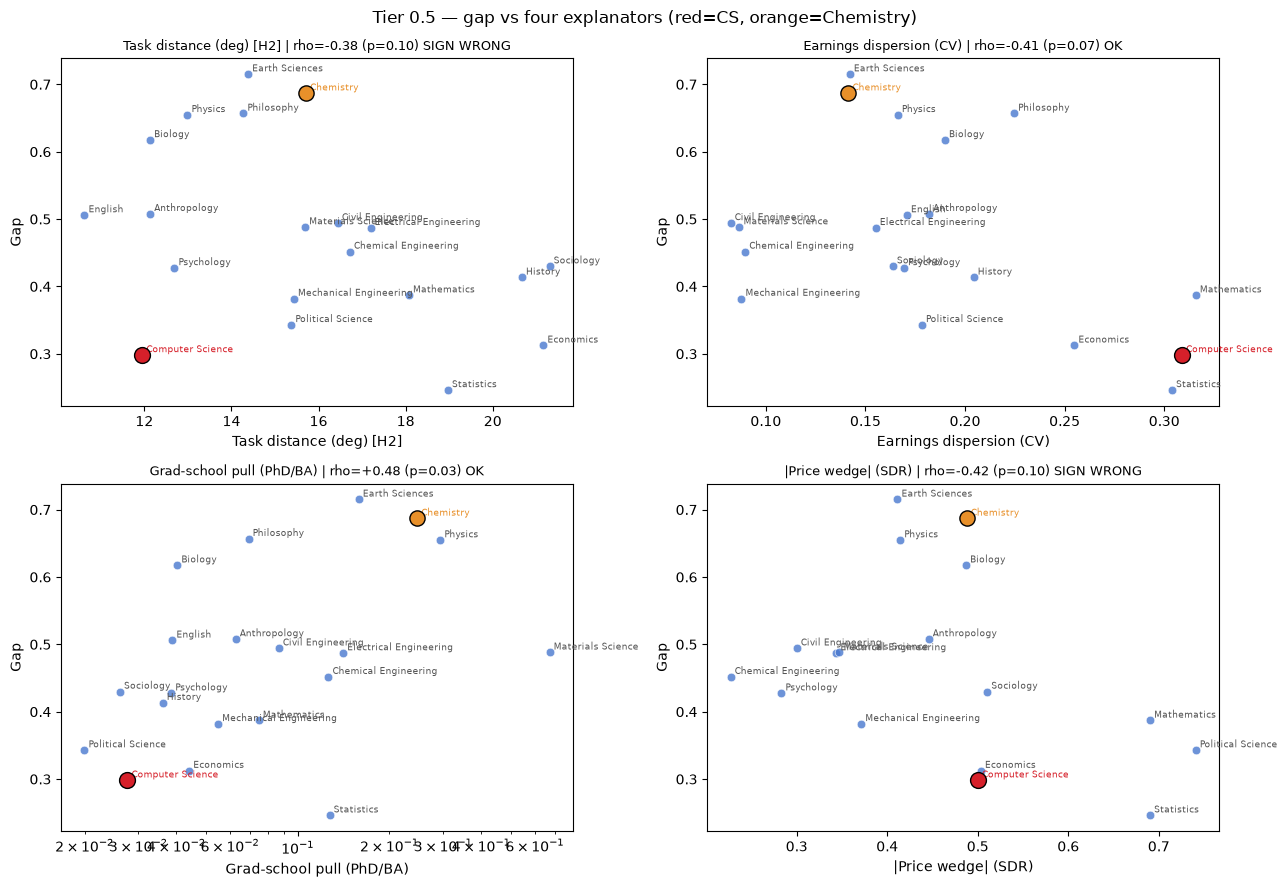

In [6]:
LABELS = {"task_distance": "Task distance (deg) [H2]", "earn_cv": "Earnings dispersion (CV)",
          "doc_ba_ratio": "Grad-school pull (PhD/BA)", "price_wedge_abs": "|Price wedge| (SDR)"}
CS, CH = "computer_science", "chemistry"

def scat(ax, m, v, logx=False):
    o = m[~m.field_key.isin([CS, CH])]
    ax.scatter(o[v], o.gap, s=38, c="#4878CF", alpha=.8, edgecolor="white", lw=.5)
    ax.scatter(m[m.field_key == CH][v], m[m.field_key == CH].gap, s=120, c="#E8902A", edgecolor="k", zorder=5)
    ax.scatter(m[m.field_key == CS][v], m[m.field_key == CS].gap, s=130, c="#D6202A", edgecolor="k", zorder=5)
    for _, r in m.iterrows():
        c = "#D6202A" if r.field_key == CS else "#E8902A" if r.field_key == CH else "#555"
        ax.annotate(r.label, (r[v], r.gap), fontsize=6.3, xytext=(3, 2), textcoords="offset points", color=c)
    if logx: ax.set_xscale("log")

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, v in zip(axes.ravel(), LABELS):
    m = g.dropna(subset=[v]); scat(ax, m, v, logx=(v == "doc_ba_ratio"))
    rho, p = spearmanr(m[v], m.gap); pred = T5.EXPLANATORS[v][0]
    ax.set_title(f"{LABELS[v]} | rho={rho:+.2f} (p={p:.2f}) "
                 f"{'OK' if np.sign(rho)==pred else 'SIGN WRONG'}", fontsize=9)
    ax.set_xlabel(LABELS[v]); ax.set_ylabel("Gap")
fig.suptitle("Tier 0.5 — gap vs four explanators (red=CS, orange=Chemistry)")
fig.tight_layout(); plt.show()

### Verdict — **REFRAME**

Task distance (H2) does not explain the gap and is **signed backwards**; chemistry (low
task distance, high gap) refutes it. The gap is organized by an **academic-pipeline /
earnings-informativeness axis** — grad-school pull (+0.48, significant) and earnings
dispersion (−0.41) — which correctly places both CS and chemistry. The price wedge (PRICE
agreement) does not coincide with the institution-level RANK gap. **Do not start the
ORCID+OpenAlex pipeline (Step 5)**; re-specify the gap to be robust to earnings
informativeness, or reframe the question around the pipeline mechanism. Full write-up:
`notes/TIER0_5_RESULT.md`.